In [1]:
import os
print(os.getcwd())
os.listdir()

import sys
#!{sys.executable} -m pip install scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import json

from etco2process import etco2_process
from find_etco2_delay import find_etco2_delay
from voxelwise_cvr import voxelwise_cvr

# file path to where data is stored - CHANGE
path = "/Users/tenio/MATLAB/CONNExIN/2025/Data/"
sub = "sub-001"

physio_file = path + sub + "/func/" + sub + "_task-gas_physio.tsv"
print(physio_file)
co2recording = pd.read_csv(physio_file, sep="\s+",header=None,names=['rawflow', 'co2'])

print(f"Raw flow range: {co2recording['rawflow'].min():.2f} to {co2recording['rawflow'].max():.2f} m³/s")
print(f"CO2 range: {co2recording['co2'].min():.2f} to {co2recording['co2'].max():.2f} %")

/Users/tenio/MATLAB/CONNExIN/2025
/Users/tenio/MATLAB/CONNExIN/2025/Data/sub-001/func/sub-001_task-gas_physio.tsv
Raw flow range: -48.46 to 47.20 m³/s
CO2 range: 0.10 to 6.11 %


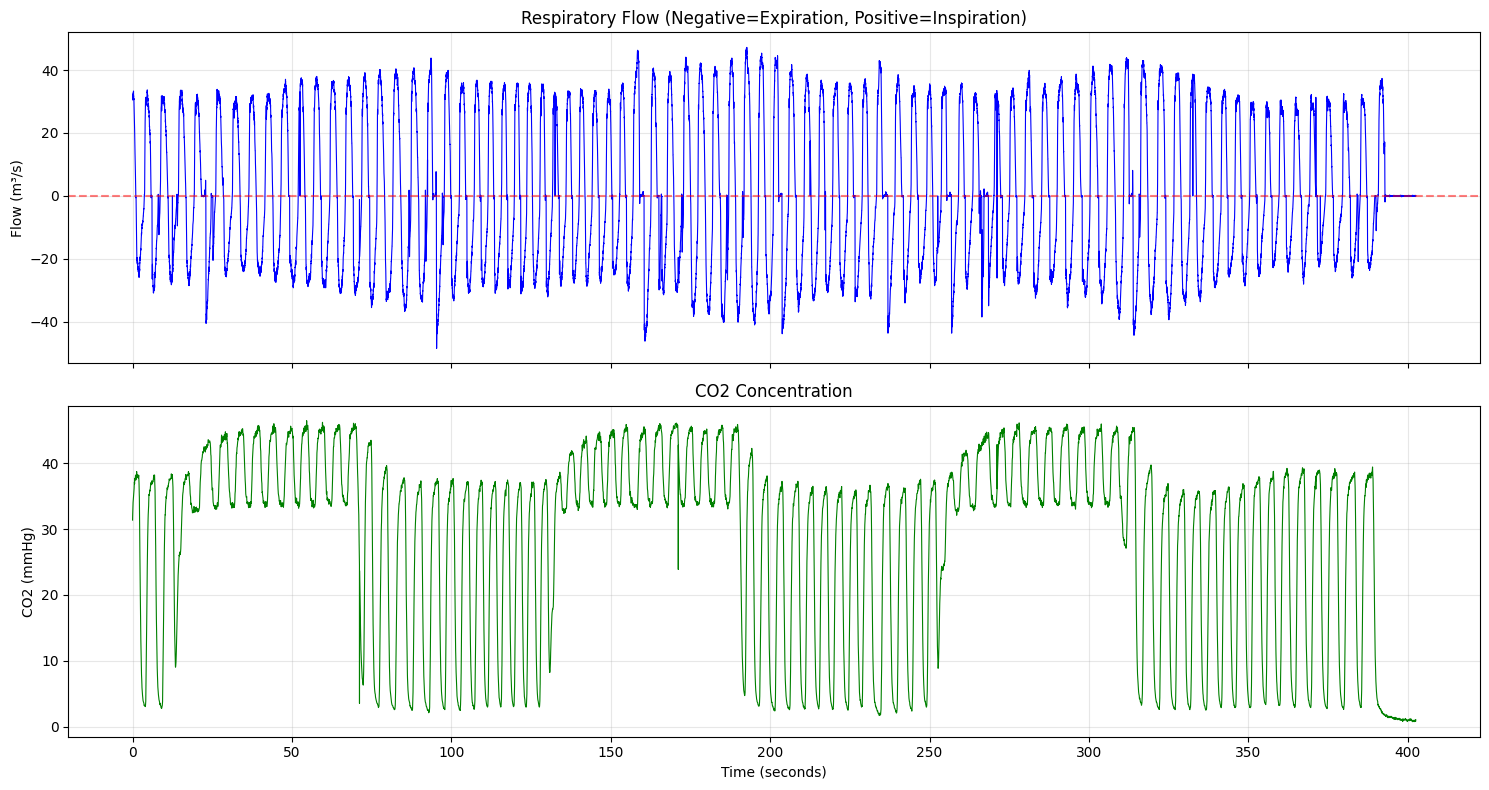

In [2]:
f = 100  # Hz
time_seconds = np.arange(len(co2recording)) / f
co2 = co2recording['co2'] * 7.6

# Create the new variable with time and CO2 in mmHg
co2_data = pd.DataFrame({
    'time': time_seconds,
    'co2': co2
    })

# Plot both signals
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Respiratory flow
ax1.plot(time_seconds, co2recording['rawflow'], 'b-', linewidth=0.8)
ax1.set_ylabel('Flow (m³/s)')
ax1.set_title('Respiratory Flow (Negative=Expiration, Positive=Inspiration)')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)

# CO2 concentration
ax2.plot(time_seconds, co2_data['co2'], 'g-', linewidth=0.8)
ax2.set_ylabel('CO2 (mmHg)')
ax2.set_xlabel('Time (seconds)')
ax2.set_title('CO2 Concentration')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


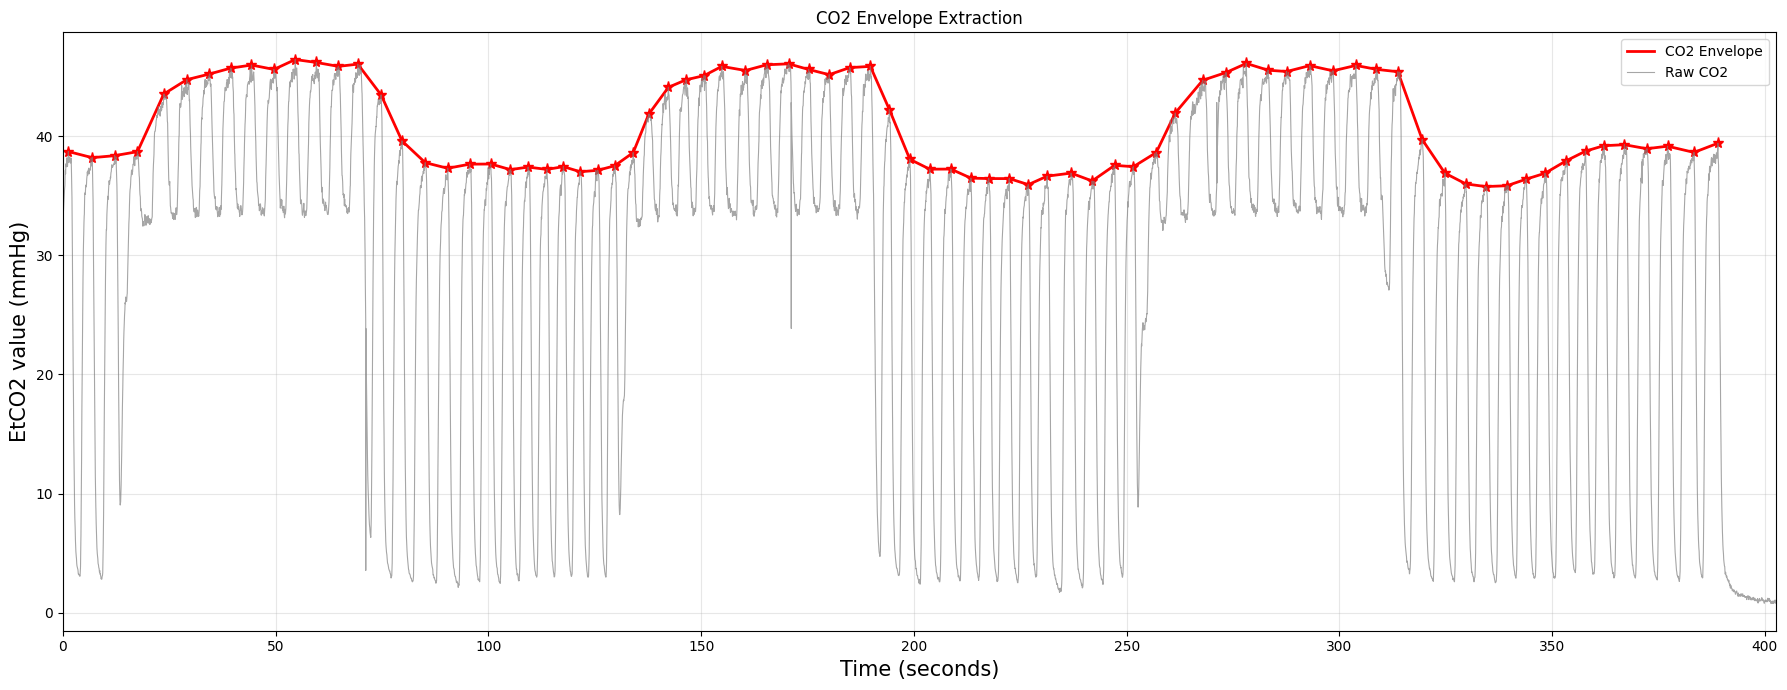

In [3]:
etco2file = path + "derivatives/fsl/" + sub + "/func/" + sub + "_etco2_envelope.txt"
timepeaks, co2envlp = etco2_process(co2_data,etco2file, SR=100, min_prctile=60)

Whole-brain signal mean: 6531.858453441668
Grey-matter signal mean: 4831.802742891668


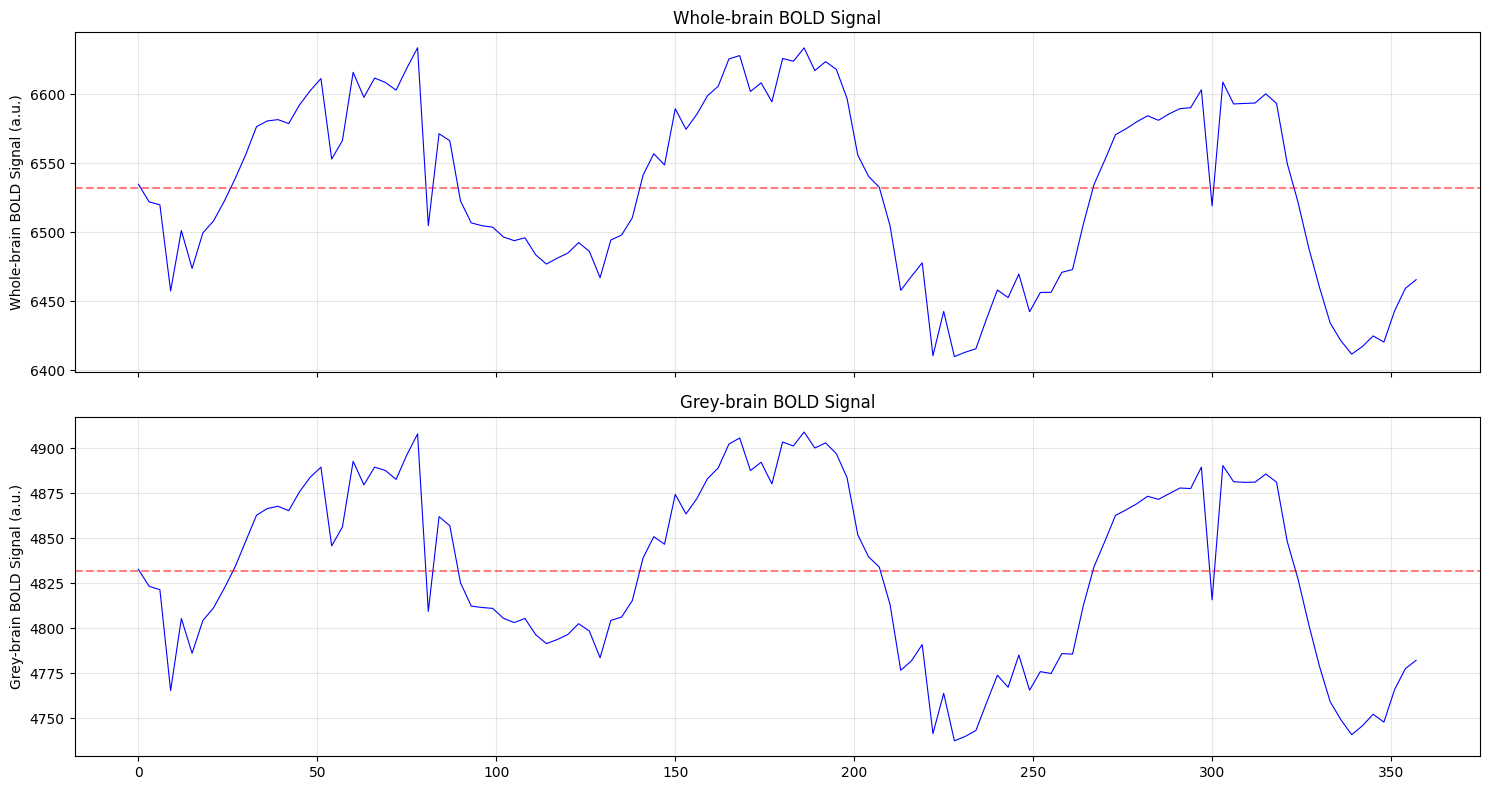

In [4]:
# Load the JSON sidecar (same name as the NIfTI file)
with open(path + sub + "/func/" + sub + "_task-gas_bold.json", "r") as f:
    meta = json.load(f)
TR = meta.get("RepetitionTime", None)

# Read whole-brain and grey-matter BOLD signals
wb_bold_file = path + "derivatives/fsl/" + sub + "/func/" + sub + "_task-gas_space-MNI152NLin2009cAsym_desc-WBsignal_timeseries.txt"
wb_bold = np.loadtxt(wb_bold_file)
print("Whole-brain signal mean:", np.mean(wb_bold))
gm_bold_file = path + "derivatives/fsl/" + sub + "/func/" + sub + "_task-gas_space-MNI152NLin2009cAsym_desc-GMsignal_timeseries.txt"
gm_bold = np.loadtxt(gm_bold_file)
print("Grey-matter signal mean:", np.mean(gm_bold))
time = np.arange(len(wb_bold))*TR

# Plot both signals
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Whole-brain BOLD signal
ax1.plot(time, wb_bold, 'b-', linewidth=0.8)
ax1.set_ylabel('Whole-brain BOLD Signal (a.u.)')
ax1.set_title('Whole-brain BOLD Signal')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=np.mean(wb_bold), color='red', linestyle='--', alpha=0.5)

# Grey-matter BOLD signal
ax2.plot(time, gm_bold, 'b-', linewidth=0.8)
ax2.set_ylabel('Grey-brain BOLD Signal (a.u.)')
ax2.set_title('Grey-brain BOLD Signal')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=np.mean(gm_bold), color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Optimal whole-brain delay: 6.57 seconds


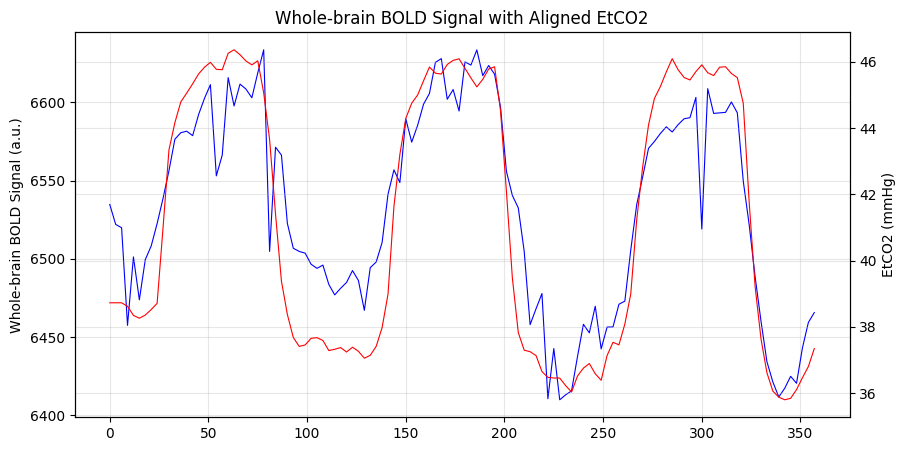

In [5]:
# Shift EtCO2
etco2file = path + "derivatives/fsl/" + sub + "/func/" + sub + "_etco2_envelope.txt"
etco2_timecourse = np.loadtxt(etco2file)
opt_wb_delay, wb_etco2 = find_etco2_delay(wb_bold, etco2_timecourse, TR, [-10, 10])

print("Optimal whole-brain delay: " + str(round(opt_wb_delay,2)) + " seconds")
fig, ax1 = plt.subplots(figsize=(10,5))

# Whole-brain BOLD signal
ax1.plot(time, wb_bold, 'b-', linewidth=0.8)
ax1.set_ylabel('Whole-brain BOLD Signal (a.u.)')
ax1.grid(True, alpha=0.3)

# Aligned EtCO2
ax2 = ax1.twinx()
ax2.plot(time, wb_etco2, 'r-', linewidth=0.8)
ax2.set_ylabel('EtCO2 (mmHg)')
ax2.grid(True, alpha=0.3)

plt.title("Whole-brain BOLD Signal with Aligned EtCO2")
plt.show()

Optimal grey-matter delay: 6.69 seconds


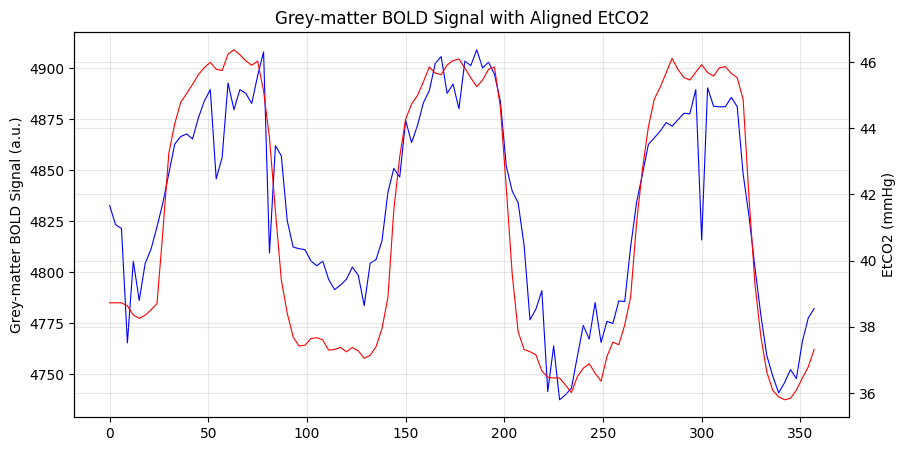

In [6]:
opt_gm_delay, gm_etco2 = find_etco2_delay(gm_bold, etco2_timecourse, TR, [-10, 10])

print("Optimal grey-matter delay: " + str(round(opt_gm_delay,2)) + " seconds")
fig, ax1 = plt.subplots(figsize=(10,5))

# Grey-matter BOLD signal
ax1.plot(time, gm_bold, 'b-', linewidth=0.8)
ax1.set_ylabel('Grey-matter BOLD Signal (a.u.)')
ax1.grid(True, alpha=0.3)

# Aligned EtCO2
ax2 = ax1.twinx()
ax2.plot(time, gm_etco2, 'r-', linewidth=0.8)
ax2.set_ylabel('EtCO2 (mmHg)')
ax2.grid(True, alpha=0.3)

plt.title("Grey-matter BOLD Signal with Aligned EtCO2")
plt.show()

In [7]:
# Read the .par file (space-delimited)
motionfile = path + "derivatives/fsl/" + sub + "/func/" + sub + "_task-gas_desc-mc_bold.par"
motion = pd.read_csv(motionfile, sep="\s+", header=None,dtype=float)
motion_array = motion.values
# ["rot_x", "rot_y", "rot_z", "trans_x", "trans_y", "trans_z"]

In [8]:
from sklearn.linear_model import LinearRegression

# Whole-brain CVR
wb_etco2 = wb_etco2 - np.mean(wb_etco2)
b_etco2 = np.mean(wb_etco2[wb_etco2 < np.percentile(wb_etco2, 25)])
X = np.column_stack([wb_etco2, motion_array,np.arange(len(wb_bold))]) #design matrix
model = LinearRegression().fit(X, wb_bold)
beta_co2 = model.coef_[0]  
wb_bold0 = model.intercept_
wb_cvr = 100 * beta_co2 / (wb_bold0 + (beta_co2 * b_etco2))
print("Whole-brain CVR for " + sub + ": " + str(round(wb_cvr,4)) + "%/mmHg")

# Grey-matter CVR
gm_etco2 = gm_etco2 - np.mean(gm_etco2)
b_etco2 = np.mean(gm_etco2[gm_etco2 < np.percentile(gm_etco2, 25)])
X = np.column_stack([gm_etco2, motion_array,np.arange(len(gm_bold))]) #design matrix
model = LinearRegression().fit(X, gm_bold)
beta_co2 = model.coef_[0]  
gm_bold0 = model.intercept_
gm_cvr = 100 * beta_co2 / (gm_bold0 + (beta_co2 * b_etco2))

print("Grey-matter CVR for " + sub + ": " + str(round(gm_cvr,4)) + "%/mmHg")

output_data = np.column_stack([wb_cvr, gm_cvr])
output_file = path + "derivatives/fsl/" + sub + "/cvr/" + sub + "_CVRvalues.txt"
np.savetxt(output_file, output_data, delimiter='\t', header="WBcvr \t GMcvr",comments='')

print(f"Saved CVR timeseries to {output_file}")

Whole-brain CVR for sub-001: 0.2058%/mmHg
Grey-matter CVR for sub-001: 0.2123%/mmHg
Saved CVR timeseries to /Users/tenio/MATLAB/CONNExIN/2025/Data/derivatives/fsl/sub-001/cvr/sub-001_CVRvalues.txt


In [ ]:
bold_file = path + "derivatives/fsl/" + sub + "/func/" + sub + "_task-gas_space-MNI152NLin2009cAsym_desc-preproc-smooth_bold.nii.gz"
mask_file = path + "derivatives/fsl/" + sub + "/func/" + sub + "_task-gas_space-MNI152NLin2009cAsym_desc-brain_mask.nii.gz"

beta_map, cvr_map, lag_map = voxelwise_cvr(func_file=bold_file,etco2=wb_etco2,wbsignal=wb_bold,mask_file=mask_file,tr=TR,motion=motion_array)

Progress: 0.0% (1/228453 voxels)


In [ ]:
import os
import nibabel as nib

# Example folder to save outputs
outdir = path + "derivatives/fsl/" + sub + "/cvr/"
os.makedirs(outdir, exist_ok=True)

bold_img = nib.load(bold_file)

# Save beta_map
beta_file = os.path.join(outdir, sub + "_beta_map.nii.gz")
nib.save(nib.Nifti1Image(beta_map, affine=bold_img.affine, header=bold_img.header), beta_file)

# Save cvr_map
cvr_file = os.path.join(outdir, sub + "_cvr_map.nii.gz")
nib.save(nib.Nifti1Image(cvr_map, affine=bold_img.affine, header=bold_img.header), cvr_file)

# Save lag_map
lag_file = os.path.join(outdir, sub + "_lag_map.nii.gz")
nib.save(nib.Nifti1Image(lag_map, affine=bold_img.affine, header=bold_img.header), lag_file)

print(f"Saved beta_map to {beta_file}")
print(f"Saved cvr_map to {cvr_file}")
print(f"Saved lag_map to {lag_file}")
